# ...

In [14]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

train_pattern = re.compile(
    r"^\s*(?P<epoch>\d+)/\d+\s+"
    r"(?P<gpu_mem>[\d.]+)[Gg]\s+"
    r"(?P<box_loss>[\d.]+)\s+"
    r"(?P<cls_loss>[\d.]+)\s+"
    r"(?P<dfl_loss>[\d.]+)", 
    re.MULTILINE
)
val_pattern = re.compile(
    r"^\s*(?P<class_name>all)\s+"
    r"(?P<images>\d+)\s+"
    r"(?P<instances>\d+)\s+"
    r"(?P<precision>[\d.]+)\s+"
    r"(?P<recall>[\d.]+)\s+"
    r"(?P<mAP50>[\d.]+)\s+"
    r"(?P<mAP50_95>[\d.]+)", 
    re.MULTILINE
)

def cast_type(value):
    try: return float(value) if '.' in value else int(value)
    except ValueError: return value

In [15]:
def parse_log(log, continuous_epochs=True):
    """
    continuous_epochs=True: нумерует эпохи строго по порядку (1, 2, 3...)
    continuous_epochs=False: берет номера эпох прямо из текста лога.
    """
    parsed_data = defaultdict(list)
    for match in train_pattern.finditer(log):
        for key, val in match.groupdict().items():
            parsed_data[key].append(cast_type(val))
    for match in val_pattern.finditer(log):
        for key, val in match.groupdict().items():
            parsed_data[key].append(cast_type(val))
    num_entries = len(parsed_data.get('box_loss',[]))
    if continuous_epochs and num_entries > 0:
        parsed_data['epoch'] = list(range(1, num_entries + 1))        
    return dict(parsed_data)


def plot_yolo_dashboard(parsed_data, marker=False):
    epochs = parsed_data.get('epoch',[])
    if not epochs:
        print("Ошибка: Нет данных для отрисовки!")
        return
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    loss_metrics = ['box_loss', 'cls_loss', 'dfl_loss']
    marker_style = {'marker':'o','marksize':4} if marker else {}
    for m in loss_metrics:
        if m in parsed_data:
            axes[0].plot(epochs, parsed_data[m], linewidth=2.5, label=m, **marker_style)
    axes[0].set_ylim(bottom=0.0) 
    axes[0].set_title('График потерь (Train Loss)', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Эпоха', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(fontsize=11)
    eval_metrics =['precision', 'recall', 'mAP50', 'mAP50_95']
    marker_style = {'marker':'s','marksize':4} if marker else {}
    for m in eval_metrics:
        if m in parsed_data:
            axes[1].plot(epochs, parsed_data[m], linewidth=2.5, label=m, **marker_style)
    axes[1].set_ylim(0.0, 1.05)
    axes[1].set_title('Метрики качества (mAP, P, R)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Эпоха', fontsize=12)
    axes[1].set_ylabel('Значение', fontsize=12)
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=11)
    plt.tight_layout(); plt.show()


def plot(log, marker=False):
    parsed = parse_log(log) if isinstance(log, str) else log
    if not isinstance(parsed, dict): raise ValueError
    plot_yolo_dashboard(parsed, marker)

# job

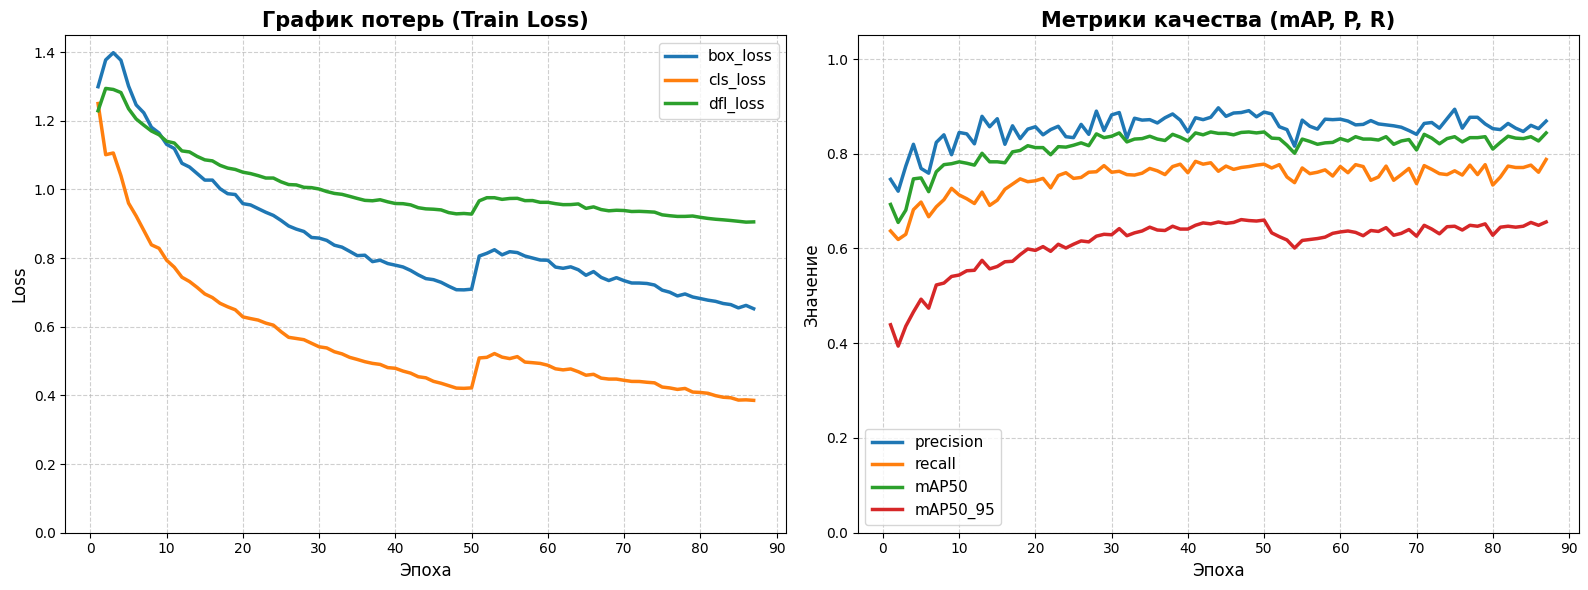

In [16]:
plot("""
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=True, resume=False, retina_masks=False, rle=1.0, save=True, save_conf=False, save_crop=False, save_dir=/content/runs/detect/train4, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=42, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=2, workspace=None
Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1   1642496  ultralytics.nn.modules.block.C3k2            [1024, 512, 1, True]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1    542720  ultralytics.nn.modules.block.C3k2            [1024, 256, 1, True]          
 17                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1   1511424  ultralytics.nn.modules.block.C3k2            [768, 512, 1, True]           
 20                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 21            [-1, 10]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 22                  -1  1   1642496  ultralytics.nn.modules.block.C3k2            [1024, 512, 1, True]          
 23        [16, 19, 22]  1   1412566  ultralytics.nn.modules.head.Detect           [2, 16, None, [256, 512, 512]]
YOLO11m summary: 232 layers, 20,054,550 parameters, 20,054,534 gradients, 68.2 GFLOPs

Transferred 643/649 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2472.6±621.6 MB/s, size: 242.9 KB)
train: Scanning /content/data_split/train/labels.cache... 3017 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3017/3017 1.2Git/s 0.0s
train: /content/data_split/train/images/0209-10_00867800.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-10_00890700.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-10_00974200.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-26_00868900.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-26_00871800.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-27_00944300.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-35_00882200.jpg: 1 duplicate labels removed
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
train: Caching images (2.6GB RAM): 100% ━━━━━━━━━━━━ 3017/3017 125.7it/s 24.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 924.0±1050.9 MB/s, size: 203.9 KB)
val: Scanning /content/data_split/val/labels.cache... 891 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 891/891 34.9Mit/s 0.0s
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.8GB RAM): 100% ━━━━━━━━━━━━ 891/891 92.6it/s 9.6s
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Plotting labels to /content/runs/detect/train4/labels.jpg... 
Image sizes 736 train, 736 val
Using 2 dataloader workers
Logging results to /content/runs/detect/train4
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50      13.4G      1.299       1.25      1.229         47        736: 100% ━━━━━━━━━━━━ 189/189 1.7it/s 1:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.9it/s 15.0s
                   all        891       3300      0.746      0.637      0.693      0.439

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      13.5G      1.377      1.101      1.294         33        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.6it/s 10.6s
                   all        891       3300      0.721      0.619      0.655      0.394

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      13.5G      1.398      1.106      1.291         39        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.5s
                   all        891       3300      0.774       0.63      0.681      0.436

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      13.5G      1.376       1.04      1.282         35        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300       0.82      0.682      0.747      0.466

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/50      13.5G      1.301     0.9599      1.235         47        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.769      0.698      0.749      0.493

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/50      13.5G      1.246     0.9224      1.205         35        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.759      0.667       0.72      0.474

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/50      13.5G      1.223     0.8805      1.187         27        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.824      0.688      0.762      0.523

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       8/50      13.5G      1.181     0.8385       1.17         45        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300       0.84      0.703      0.777      0.527

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/50      13.4G      1.164     0.8283      1.159         51        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.798      0.727      0.779      0.541

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/50      13.5G      1.131     0.7935       1.14         47        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.845      0.713      0.783      0.544

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/50      13.5G      1.119     0.7733      1.135         73        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.842      0.705       0.78      0.553

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/50      13.5G      1.076     0.7441      1.112         40        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.821      0.695      0.776      0.554

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      13/50      13.5G      1.065     0.7316      1.109         45        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.879      0.719      0.801      0.575

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      14/50      13.5G      1.046     0.7144      1.096         53        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.857      0.691      0.783      0.557

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/50      13.5G      1.027     0.6955      1.086         16        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.874      0.702      0.783      0.562

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/50      13.5G      1.027     0.6849      1.083         20        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300       0.82      0.725      0.781      0.572

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/50      13.5G      1.002     0.6682       1.07         75        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.859      0.736      0.804      0.573

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      18/50      13.5G     0.9874      0.658      1.062         52        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.832      0.747      0.807      0.587

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/50      13.5G      0.985     0.6493      1.058         48        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300      0.852      0.741      0.817      0.599

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/50      13.5G     0.9584     0.6286       1.05         55        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.857      0.743      0.813      0.596

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      21/50      13.4G     0.9547     0.6237      1.046         63        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300       0.84      0.748      0.813      0.604

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      22/50      13.5G     0.9439     0.6193       1.04         36        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.851      0.728      0.798      0.594

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      23/50      13.5G     0.9333     0.6105      1.033         59        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.858      0.754      0.815      0.609

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      24/50      13.5G     0.9241     0.6045      1.033         53        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.836       0.76      0.814      0.601

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      25/50      13.4G     0.9096     0.5856      1.022         65        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.834      0.748      0.818      0.609

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      26/50      13.5G     0.8934     0.5691      1.014         61        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.862       0.75      0.823      0.616

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      27/50      13.5G     0.8843     0.5657      1.013         51        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.841      0.761      0.817      0.614

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      28/50      13.5G     0.8774     0.5622      1.006         33        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300       0.89      0.762      0.842      0.626

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/50      13.5G     0.8599     0.5518      1.005         44        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.8s
                   all        891       3300      0.849      0.775      0.834       0.63

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/50      13.5G     0.8581     0.5415      1.001         36        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.882      0.761      0.837      0.629

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      31/50      13.5G     0.8514     0.5382     0.9937         45        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.8s
                   all        891       3300      0.887      0.763      0.844      0.642

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      32/50      13.5G     0.8374     0.5271     0.9882         64        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.833      0.756      0.825      0.627

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      33/50      13.4G     0.8317     0.5209     0.9855         39        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.875      0.755      0.831      0.633

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      34/50      13.5G     0.8196     0.5108     0.9797         46        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.871      0.759      0.832      0.637

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      35/50      13.5G      0.807     0.5047     0.9736         51        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.872      0.769      0.837      0.645

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      36/50      13.5G     0.8082     0.4981      0.968         68        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.865      0.764      0.831      0.639

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/50      13.5G     0.7896     0.4932     0.9668         53        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.876      0.756      0.828      0.638

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      38/50      13.5G     0.7937     0.4902     0.9698         60        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.884      0.773      0.841      0.647

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      39/50      13.5G      0.784     0.4809     0.9637         41        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.871      0.778      0.835      0.641

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      40/50      13.5G     0.7792     0.4789     0.9588         36        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.846       0.76      0.827      0.641
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      41/50      13.5G      0.774     0.4708     0.9583         54        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.876      0.784      0.844      0.649

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      42/50      13.5G     0.7639     0.4648     0.9549         39        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.872      0.778       0.84      0.654

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      43/50      13.5G      0.751     0.4543     0.9466         52        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.877      0.781      0.846      0.652

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      44/50      13.5G     0.7401     0.4512     0.9432         64        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.897      0.763      0.843      0.656

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      45/50      13.5G      0.737     0.4409     0.9422         38        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.879      0.774      0.843      0.653

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      46/50      13.5G     0.7293     0.4353     0.9402         43        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.886      0.767       0.84      0.655

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      47/50      13.5G     0.7179     0.4283     0.9323         51        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300      0.887      0.771      0.845      0.661

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      48/50      13.5G     0.7077     0.4212     0.9287         78        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.891      0.773      0.846      0.659

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      49/50      13.4G     0.7073     0.4205     0.9298         52        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.878      0.776      0.844      0.658

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50      13.5G     0.7093     0.4218      0.928         42        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.888      0.778      0.846       0.66

50 epochs completed in 1.655 hours.
Optimizer stripped from /content/runs/detect/train4/weights/last.pt, 40.5MB
Optimizer stripped from /content/runs/detect/train4/weights/best.pt, 40.5MB

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train4/weights/last.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train4_continued, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=/content/runs/detect, rect=True, resume=False, retina_masks=False, rle=1.0, save=True, save_conf=False, save_crop=False, save_dir=/content/runs/detect/train4_continued, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=42, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=1.0, warmup_momentum=0.8, weight_decay=0.0005, workers=2, workspace=None

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1   1642496  ultralytics.nn.modules.block.C3k2            [1024, 512, 1, True]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1    542720  ultralytics.nn.modules.block.C3k2            [1024, 256, 1, True]          
 17                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1   1511424  ultralytics.nn.modules.block.C3k2            [768, 512, 1, True]           
 20                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 21            [-1, 10]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 22                  -1  1   1642496  ultralytics.nn.modules.block.C3k2            [1024, 512, 1, True]          
 23        [16, 19, 22]  1   1412566  ultralytics.nn.modules.head.Detect           [2, 16, None, [256, 512, 512]]
YOLO11m summary: 232 layers, 20,054,550 parameters, 20,054,534 gradients, 68.2 GFLOPs

Transferred 649/649 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 104.5±11.6 MB/s, size: 265.5 KB)
train: Scanning /content/data_split/train/labels.cache... 3017 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3017/3017 468.7Mit/s 0.0s
train: /content/data_split/train/images/0209-10_00867800.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-10_00890700.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-10_00974200.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-26_00868900.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-26_00871800.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-27_00944300.jpg: 1 duplicate labels removed
train: /content/data_split/train/images/0209-35_00882200.jpg: 1 duplicate labels removed
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
train: Caching images (2.6GB RAM): 100% ━━━━━━━━━━━━ 3017/3017 100.6it/s 30.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 58.1±21.5 MB/s, size: 206.9 KB)
val: Scanning /content/data_split/val/labels.cache... 891 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 891/891 49.2Mit/s 0.0s
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.8GB RAM): 100% ━━━━━━━━━━━━ 891/891 92.4it/s 9.6s
optimizer: AdamW(lr=0.0005, momentum=0.937) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Plotting labels to /content/runs/detect/train4_continued/labels.jpg... 
Image sizes 736 train, 736 val
Using 2 dataloader workers
Logging results to /content/runs/detect/train4_continued
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50      6.03G     0.8058      0.509     0.9666         47        736: 100% ━━━━━━━━━━━━ 189/189 1.8it/s 1:43
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.9it/s 14.4s
                   all        891       3300      0.884       0.77      0.833      0.633

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      7.18G     0.8138     0.5108     0.9757         33        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:25
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.857      0.777      0.832      0.625

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      7.21G     0.8242     0.5218     0.9757         39        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.851      0.751      0.818      0.618

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      7.21G     0.8093     0.5114     0.9709         35        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.816      0.739      0.801      0.601

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/50      7.21G     0.8185     0.5071     0.9735         47        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.871       0.77      0.831      0.617

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/50      7.21G     0.8159     0.5129     0.9739         35        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.858      0.758      0.826      0.619

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/50      7.21G     0.8058      0.497     0.9672         27        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.852      0.761       0.82      0.621

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       8/50      7.21G        0.8     0.4952     0.9674         45        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300      0.873      0.766      0.823      0.624

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/50      7.21G     0.7942     0.4931     0.9623         51        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.7s
                   all        891       3300      0.872      0.753      0.824      0.632

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/50      7.21G     0.7936     0.4877     0.9623         47        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.873      0.773      0.832      0.635

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/50      7.21G     0.7737     0.4774     0.9584         73        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.869       0.76      0.827      0.637

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/50      7.21G     0.7701     0.4743     0.9555         40        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.861      0.777      0.836      0.634

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      13/50      7.21G     0.7744      0.477     0.9557         45        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.862      0.773      0.831      0.627

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      14/50      7.21G     0.7659     0.4689     0.9576         53        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300       0.87      0.744      0.831      0.638

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/50      7.21G     0.7498     0.4587     0.9446         16        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.863      0.751      0.829      0.636

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/50      7.21G     0.7606     0.4614      0.949         20        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.861      0.774      0.836      0.644

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/50      7.21G     0.7436     0.4502     0.9412         75        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.859      0.744       0.82      0.628

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      18/50      7.21G     0.7345     0.4475     0.9376         52        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.856      0.756      0.827      0.632

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/50      7.21G     0.7428     0.4475     0.9392         48        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.849      0.769       0.83       0.64

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/50      7.21G     0.7341     0.4439     0.9384         55        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.841      0.737      0.808      0.626

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      21/50      7.21G     0.7273     0.4407     0.9355         63        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300      0.864      0.775      0.841      0.649

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      22/50      7.21G     0.7272     0.4405      0.936         36        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.2s
                   all        891       3300      0.866      0.767      0.833      0.641

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      23/50      7.21G     0.7259     0.4382      0.935         59        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.854      0.758      0.821      0.631

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      24/50      7.21G     0.7214     0.4365     0.9337         53        736: 100% ━━━━━━━━━━━━ 189/189 2.2it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.874      0.756      0.832      0.646

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      25/50      7.21G     0.7065     0.4243     0.9258         65        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.894      0.764      0.836      0.647

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      26/50      7.21G     0.7004     0.4217     0.9232         61        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.854      0.755      0.825      0.639

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      27/50      7.21G     0.6896     0.4174     0.9212         51        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.0s
                   all        891       3300      0.877      0.776      0.834      0.649

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      28/50      7.21G     0.6954     0.4202     0.9213         33        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.877      0.756      0.834      0.647

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/50      7.21G     0.6866     0.4097     0.9224         44        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        891       3300      0.863      0.777      0.836      0.652

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/50      7.21G      0.682     0.4085     0.9186         36        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.4s
                   all        891       3300      0.853      0.734       0.81      0.628

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      31/50      7.21G     0.6773     0.4061     0.9154         45        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.851      0.751      0.824      0.645

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      32/50      7.21G     0.6739     0.3992      0.913         64        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 10.1s
                   all        891       3300      0.864      0.774      0.837      0.647

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      33/50      7.21G     0.6676     0.3946     0.9113         39        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300      0.854      0.771      0.833      0.645

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      34/50      7.21G     0.6644     0.3931     0.9093         46        736: 100% ━━━━━━━━━━━━ 189/189 2.0it/s 1:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.847      0.771      0.832      0.647

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      35/50      7.21G     0.6548     0.3863      0.907         51        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        891       3300       0.86      0.776      0.836      0.655

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      36/50      7.21G     0.6621      0.387     0.9046         68        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.3s
                   all        891       3300      0.853      0.761      0.827      0.649

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/50      7.21G     0.6524     0.3855     0.9053         53        736: 100% ━━━━━━━━━━━━ 189/189 2.1it/s 1:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.7it/s 10.2s
                   all        891       3300      0.869      0.788      0.844      0.656

""")